# Fit of the VCA with magnetic end springs

Fits a nonlinear model to the chirp data in `data/train` and `data/test`:

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - F_s(x)$$

| Symbol | Meaning | Initial value |
|---|---|---|
| $m$ | moving mass | 51.5 kg (fixed) |
| $\Gamma$ | motor constant | 283 N/A (datasheet) |
| $c$ | viscous damping | 1700 N·s/m (iteration) |
| $C_\mu$ | magnet coupling constant | 2.423 N·m² (PDF eq. 13) |
| $g_0$ | magnet gap at centre | 22.3 mm (experiment) |

**Strategy.** All fits are sequential:
1. In the high band (≥ 40 Hz) the spring force is negligible, so we fit $\Gamma$ and $c$.
2. In the low band (≤ 20 Hz) we fit all parameters, starting from $\Gamma$ and $c$ of step 1. 20–40 Hz is not used.

**Discrete-time model.** RK4 with $T_s$ = 1 ms (log at 2 kHz, every other sample kept) and zero-order-hold input. Greybox fits minimise the 50-step-ahead position error, starting from the measured $(x, \dot{x})$ every 10 samples. Models are compared on position NRMSE against prediction horizon (1–500 steps), from identical initial conditions.

**Assumptions**
- Constant $\Gamma$ (PDF Assumption 1), symmetric springs, no equilibrium offset (Assumption 2).
- Input is `actual_current_A`, output is `position_mm` (converted in C, see commit `b29c717`; both datasets were logged after it).
- Current and position are zero-phase low-pass filtered (4th-order Butterworth, 100 Hz) before decimation. $\dot{x}$ is the gradient of the filtered position and is used only for initial states and LLS regressors.

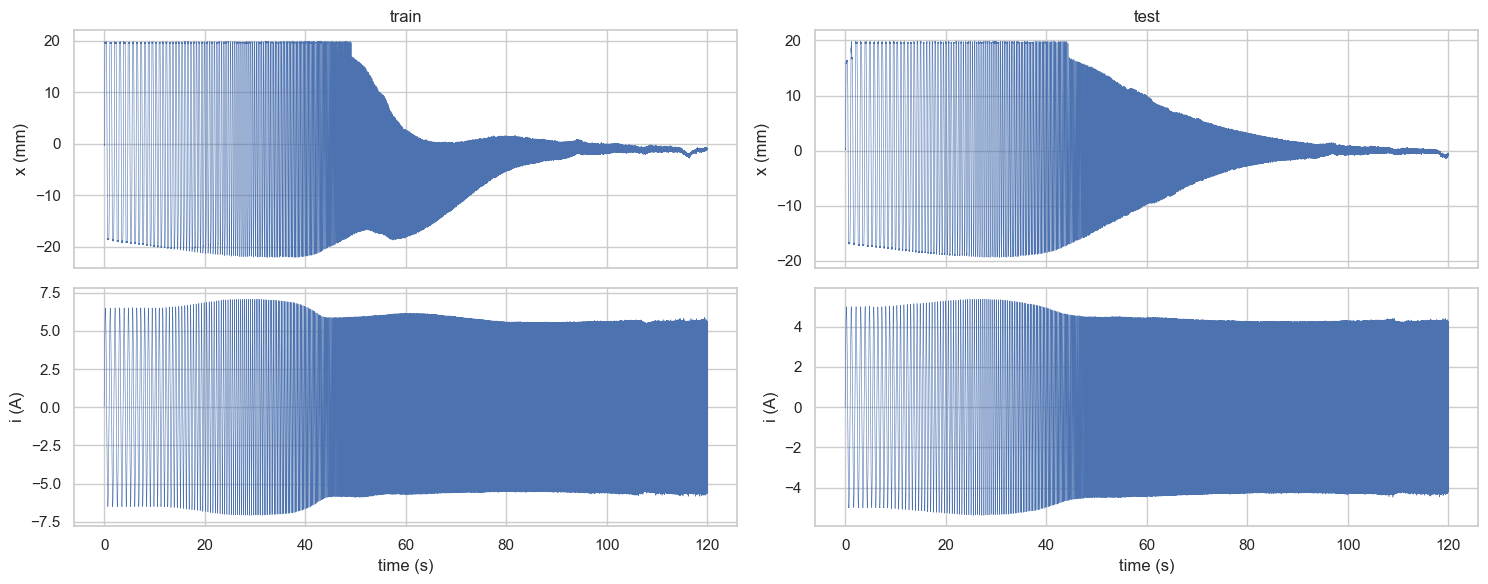

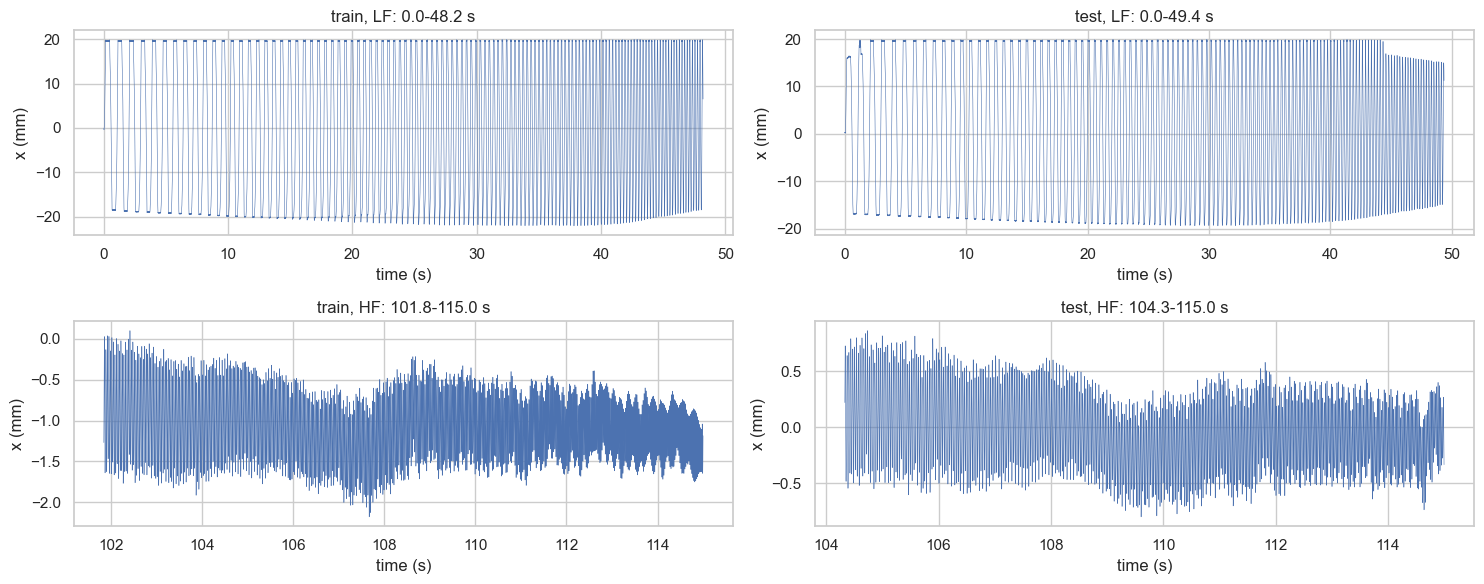

In [14]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import signal
from scipy.optimize import least_squares

sns.set_theme(style="whitegrid")

FS_LOG, DECIM = 2000.0, 2
TS = 1/1000.0                       # discretization inter-sampling time
M = 51.5                            # kg
GAMMA0, C0 = 283.0, 1700.0          # datasheet; iteration
CMU0, G00 = 2.423, 22.3e-3          # PDF eq. 13; measured gap in experiment
LF_MAX, HF_MIN = 5.0, 30.0          # Hz; Low freq range and high freq range, ub and lb
H_FIT, H_EVAL, STRIDE = 500, 500, 10 # steps for fitting the data
FOH = False                         # Zero-order hold
TAU = 0.55e-3                       # s, position is logged this much later than current; undone in load
T_CUT = 5.0                         # s, end of each run left out of the HF band

b_lp, a_lp = signal.butter(4, 100.0 / (FS_LOG / 2))   # 4th-order 100 Hz low-pass


def load(path):
    "Read one log; return filtered current and position at 1 kHz, derived v and a, and LF/HF band masks."
    # chirp start/end frequency and duration from the file name, e.g. ..._1.0to55.0Hz_120.0s_...
    f0, f1, T = map(float, re.search(r"_([\d.]+)to([\d.]+)Hz_([\d.]+)s_", path.name).groups())
    raw = np.loadtxt(path, delimiter=",", skiprows=2)   # skip header and the duplicate t = 0 row
    lp = lambda s: signal.filtfilt(b_lp, a_lp, s)       # zero-phase, also the anti-alias filter for decimation
    # columns 0 time_s, 1 actual_current_A, 11 position_mm; keep every DECIM-th sample (2 kHz -> 1 kHz)
    t = raw[:, 0]
    x = np.interp(t + TAU, t, lp(raw[:, 11] * 1e-3))   # shift position back by TAU to align it with the current
    d = dict(t=t[::DECIM], i=lp(raw[:, 1])[::DECIM], x=x[::DECIM])
    d["v"] = np.gradient(d["x"], TS)                    # velocity: initial states and LLS
    d["a"] = np.gradient(d["v"], TS)                    # acceleration: LLS only
    f = f0 * (f1 / f0) ** (d["t"] / T)                  # instantaneous frequency of the exponential chirp
    d["lf"], d["hf"] = f <= LF_MAX, (f >= HF_MIN) & (d["t"] <= d["t"][-1] - T_CUT)
    return d


DATA = {s: load(next(Path("data", s).glob("voice_coil_log_*.csv"))) for s in ("train", "test")}


def step(x, v, u0, u1, acc):
    "One RK4 step of (x, v) with input u0 at the start and u1 at the end of the step."
    um = 0.5 * (u0 + u1)
    k1x, k1v = v, acc(x, v, u0)
    k2x, k2v = v + TS / 2 * k1v, acc(x + TS / 2 * k1x, v + TS / 2 * k1v, um)
    k3x, k3v = v + TS / 2 * k2v, acc(x + TS / 2 * k2x, v + TS / 2 * k2v, um)
    k4x, k4v = v + TS * k3v, acc(x + TS * k3x, v + TS * k3v, u1)
    return x + TS / 6 * (k1x + 2 * k2x + 2 * k3x + k4x), v + TS / 6 * (k1v + 2 * k2v + 2 * k3v + k4v)


def rollout(Fs, p, d, s, H):
    "Predicted x, shape (len(s), H+1), from the measured state at each start index s. p = [Gamma, c, *spring]."
    acc = lambda x, v, u: (p[0] * u - p[1] * v - Fs(x, p[2:])) / M
    x, v, out = d["x"][s], d["v"][s], [d["x"][s]]
    with np.errstate(all="ignore"):
        for k in range(H):
            u0 = d["i"][s + k]
            x, v = step(x, v, u0, d["i"][s + k + 1] if FOH else u0, acc)
            out.append(x)
    return np.stack(out, axis=1)


def starts(d, band, H):
    "Every STRIDE-th sample of the band whose H-step horizon fits in the record."
    s = np.flatnonzero(band)[::STRIDE]
    return s[s + H < len(d["x"])]


def target(d, s, H):
    "Measured x over the horizon of each start, shape (len(s), H+1)."
    return d["x"][s[:, None] + np.arange(H + 1)]


def fit(Fs, p0, d, band, lb=-np.inf, free=slice(None), detrend=False):
    "H-step-ahead fit of p0[free]; detrend removes per-start mean and slope of the error (free-mass drift)."
    s = starts(d, band, H_FIT)
    X = target(d, s, H_FIT)[:, 1:]
    p = np.array(p0, float)
    def res(q):
        p[free] = q
        e = np.nan_to_num(rollout(Fs, p, d, s, H_FIT)[:, 1:], nan=1.0, posinf=1.0, neginf=-1.0) - X   # diverged rollout -> 1 m
        return (signal.detrend(e, axis=1) if detrend else e).ravel()
    r = least_squares(res, p[free], x_scale=np.abs(p[free]), bounds=(lb, np.inf))
    p[free] = r.x
    print(f"{r.message} ({r.nfev} evaluations)")
    return p


def nrmse_curve(Fs, p, d, band, H=H_EVAL):
    "Position RMS error per horizon step, normalised by the std of x in the band."
    s = starts(d, band, H)
    e = rollout(Fs, p, d, s, H) - target(d, s, H)
    return np.sqrt(np.mean(e ** 2, axis=0)) / np.std(d["x"][band])


CURVES = []

def evaluate(name, Fs, p, band, H=H_EVAL):
    "Left: NRMSE against horizon, train and test. Right: one H-step prediction on test, started mid-band."
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    k = np.arange(1, H + 1)
    for split, d in DATA.items():
        e = nrmse_curve(Fs, p, d, d[band], H)[1:]
        CURVES.append(dict(method=name, split=split, band=band, k=k, nrmse=e))   # kept for the comparison cell
        sns.lineplot(x=k, y=e, ax=ax[0], label=split)
        print(f"{split:5s} NRMSE at k = 1, 10, 100, {H}: " + ", ".join(f"{e[j - 1]:.3f}" for j in (1, 10, 100, H)))
    ax[0].set(xscale="log", xlabel="steps ahead (1 step = 1 ms)", ylabel="position NRMSE", title=f"{name}, {band.upper()} band")
    d = DATA["test"]
    s0 = starts(d, d[band], H)
    s0 = s0[len(s0) // 2:][:1]                          # one start in the middle of the band
    t = d["t"][s0[0]:s0[0] + H + 1]
    sns.lineplot(x=t, y=target(d, s0, H)[0] * 1e3, ax=ax[1], label="measured", color="k")
    sns.lineplot(x=t, y=rollout(Fs, p, d, s0, H)[0] * 1e3, ax=ax[1], label="predicted")
    ax[1].set(xlabel="time (s)", ylabel="x (mm)", title=f"test: {H}-step prediction from the measured state")
    plt.tight_layout(); plt.show()


# self-check: undamped linear spring from x = 1 mm must follow cos(wt)
_k = 1e5
_d = dict(x=np.full(2, 1e-3), v=np.zeros(2), i=np.zeros(1000))
_x = rollout(lambda x, q: q[0] * x, [0.0, 0.0, _k], _d, np.array([0]), 900)[0]
assert np.allclose(_x, 1e-3 * np.cos(np.sqrt(_k / M) * TS * np.arange(901)), atol=1e-8)

# overview: position (top) and current (bottom), train left, test right
fig, ax = plt.subplots(2, 2, figsize=(15, 6), sharex="col")
for col, (split, d) in enumerate(DATA.items()):
    sns.lineplot(x=d["t"], y=d["x"] * 1e3, ax=ax[0, col], lw=0.4).set(title=split, ylabel="x (mm)")
    sns.lineplot(x=d["t"], y=d["i"], ax=ax[1, col], lw=0.4).set(xlabel="time (s)", ylabel="i (A)")
plt.tight_layout(); plt.show()

# data actually used per band: low band (top) and high band (bottom), train left, test right
fig, ax = plt.subplots(2, 2, figsize=(15, 6))
for col, (split, d) in enumerate(DATA.items()):
    for row, band in enumerate(("lf", "hf")):
        m = d[band]
        sns.lineplot(x=d["t"][m], y=d["x"][m] * 1e3, ax=ax[row, col], lw=0.4).set(
            title=f"{split}, {band.upper()}: {d['t'][m][0]:.1f}-{d['t'][m][-1]:.1f} s", xlabel="time (s)", ylabel="x (mm)")
plt.tight_layout(); plt.show()

## Stage 1: motor constant (HF, ≥ 35 Hz)

Above 35 Hz (last `T_CUT` = 10 s of the run excluded) the mover displaces little, so the spring is taken linear. We fit $\Gamma$, $c$ and $k$ on the force balance by bounded linear least squares (`lsq_linear`, $c \geq 0$):

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - k\, x$$

In [15]:
from scipy.optimize import lsq_linear

lin_spring = lambda x, q: q[0] * x
d, sel = DATA["train"], DATA["train"]["hf"]
A = np.c_[d["i"][sel], -d["v"][sel], -d["x"][sel]]                                   # m a = Gamma i - c v - k x
p_hf = lsq_linear(A, M * d["a"][sel], bounds=([-np.inf, 0.0, -np.inf], np.inf)).x   # c >= 0
print(f"Gamma = {p_hf[0]:.1f} N/A, c = {p_hf[1]:.1f} N s/m, k = {p_hf[2]:.3g} N/m")

Gamma = 256.8 N/A, c = 1314.6 N s/m, k = 1.92e+04 N/m


Prediction with the fitted $\Gamma$, $c$ and $k$:

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - k\, x$$

train NRMSE at k = 1, 10, 100, 500: 0.005, 0.518, 2.372, 2.710
test  NRMSE at k = 1, 10, 100, 500: 0.005, 0.856, 1.706, 0.483


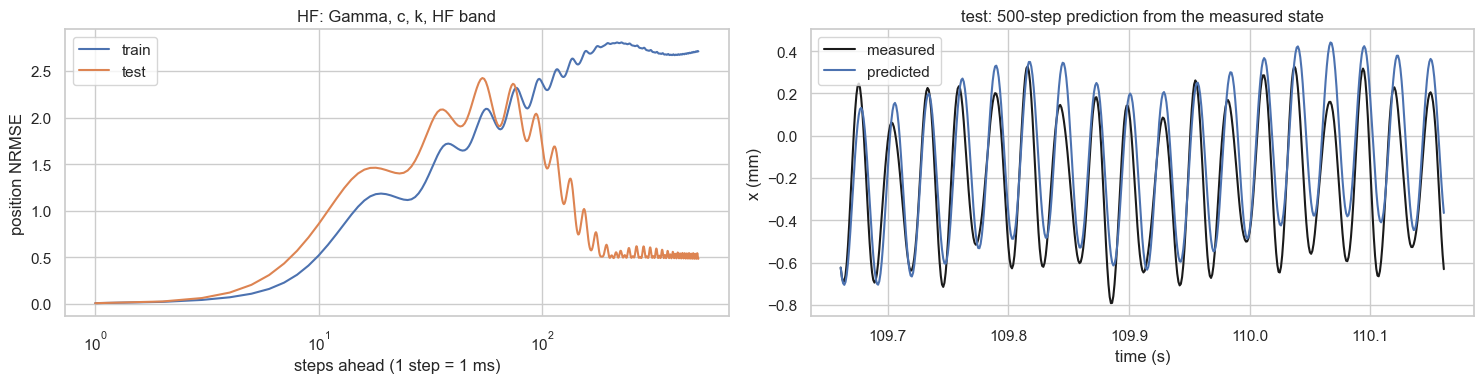

In [16]:
evaluate("HF: Gamma, c, k", lin_spring, p_hf, "hf")

## Method A: cubic spring, including even polynomial, LLS

$\Gamma$, $c$ and $k_1$ are fixed at the Stage 1 values; only $k_2$ and $k_3$ are fitted on the LF train force balance (`lstsq`). The even term makes the spring asymmetric:

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - (k_1 x + k_2 x^2 + k_3 x^3)$$

In [17]:
poly3 = lambda x, k: k[0] * x + k[1] * x**2 + k[2] * x**3
d, sel = DATA["train"], DATA["train"]["lf"]
G, c, k1 = p_hf
x = d["x"][sel]
r = M * d["a"][sel] - G * d["i"][sel] + c * d["v"][sel] + k1 * x    # force left for the higher terms: r = -(k2 x^2 + k3 x^3)
A = -np.c_[x**2, x**3]
sc = np.linalg.norm(A, axis=0)                                     # column scaling, x^3 ~ 1e-6
k2, k3 = np.linalg.lstsq(A / sc, r, rcond=None)[0] / sc
p_p3 = np.r_[p_hf, k2, k3]
print(f"Gamma = {G:.1f} N/A, c = {c:.1f} N s/m, k1 = {k1:.3g} N/m (Stage 1); k2 = {k2:.3g} N/m^2, k3 = {k3:.3g} N/m^3")

Gamma = 256.8 N/A, c = 1314.6 N s/m, k1 = 1.92e+04 N/m (Stage 1); k2 = 1.82e+05 N/m^2, k3 = 1.17e+08 N/m^3


train NRMSE at k = 1, 10, 100, 1000: 0.001, 0.055, 0.633, 0.663
test  NRMSE at k = 1, 10, 100, 1000: 0.001, 0.054, 0.618, 0.659


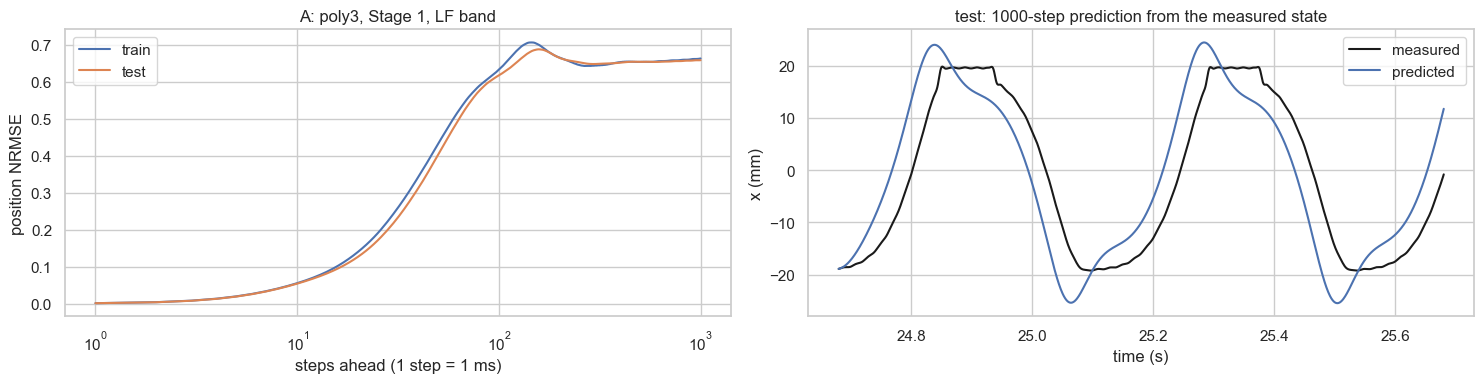

In [18]:
evaluate("A: poly3, Stage 1", poly3, p_p3, "lf", H=1000)

## Method B: polynomial spring, linear least squares

Odd polynomial spring. The model is linear in all parameters, so one `lstsq` on the continuous force balance (LF train) gives the fit; no initial guess needed:

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - (k_1 x + k_3 x^3 + k_5 x^5)$$

In [4]:
poly = lambda x, k: k[0] * x + k[1] * x**3 + k[2] * x**5
d = DATA["train"]
sel = d["lf"]
x = d["x"][sel]
A = np.c_[d["i"][sel], -d["v"][sel], -x, -x**3, -x**5]
sc = np.linalg.norm(A, axis=0)                                   # column scaling, x^5 ~ 1e-9
p_lls = np.linalg.lstsq(A / sc, M * d["a"][sel], rcond=None)[0] / sc
print("Gamma, c, k1, k3, k5 =", p_lls)

Gamma, c, k1, k3, k5 = [ 1.93096773e+02  1.81407568e+03  5.22111282e+04 -4.16035189e+08
  1.08639109e+12]


train NRMSE at k = 1, 10, 50, 500: 0.001, 0.044, 0.184, 0.345


test  NRMSE at k = 1, 10, 50, 500: 0.001, 0.045, 0.154, 0.175


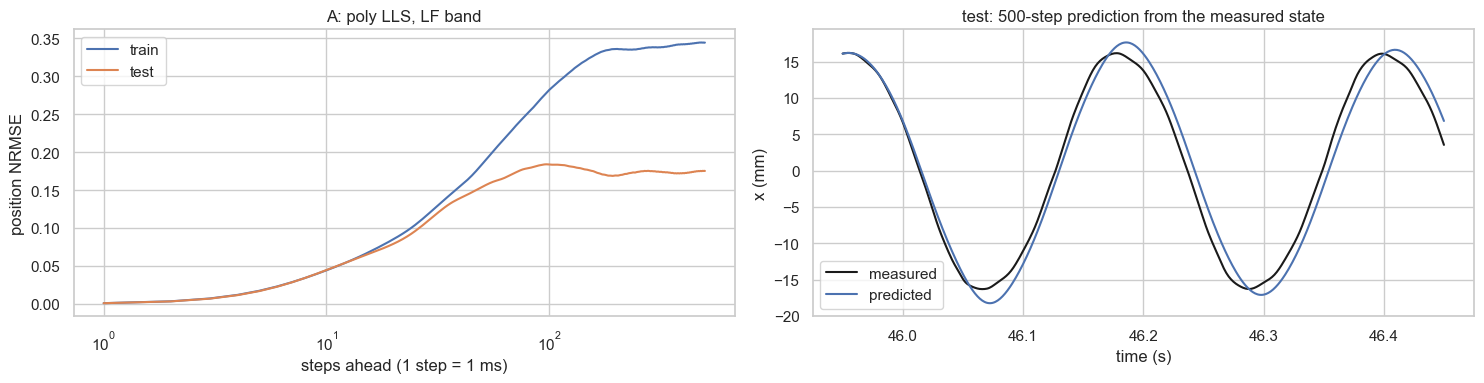

In [5]:
evaluate("B: poly LLS", poly, p_lls, "lf")

## Method C: polynomial spring, nonlinear greybox

Same model, now fitted on the 50-step-ahead error (LF train). $\Gamma$ and $c$ start from Stage 1, and the $k$'s from the Taylor expansion of the magnet law, $k_1 = 4C_\mu/g_0^3$, $k_3 = 2k_1/g_0^2$, $k_5 = 3k_1/g_0^4$:

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - (k_1 x + k_3 x^3 + k_5 x^5)$$

In [6]:
%%time
k1 = 4 * CMU0 / G00**3
p0 = np.r_[p_hf[:2], k1, 2 * k1 / G00**2, 3 * k1 / G00**4]
p_poly = fit(poly, p0, DATA["train"], DATA["train"]["lf"])
print("init  Gamma, c, k1, k3, k5 =", p0)
print("fit   Gamma, c, k1, k3, k5 =", p_poly)

C:\Users\amato\Lib\site-packages\scipy\optimize\_lsq\common.py:115: RuntimeWarning: overflow encountered in power
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm


`xtol` termination condition is satisfied. (141 evaluations)
init  Gamma, c, k1, k3, k5 = [ 2.67513282e+02 -2.73907780e+02  8.73974611e+05  3.51494947e+09
  1.06023129e+13]
fit   Gamma, c, k1, k3, k5 = [ 2.26217797e+03  1.02313316e+04 -6.10809884e+06  2.31287278e+11
 -4.50350633e+14]
CPU times: total: 2min 40s
Wall time: 2min 39s


train NRMSE at k = 1, 10, 50, 500: 0.161, 1.059, 0.767, 0.812


test  NRMSE at k = 1, 10, 50, 500: 0.168, 1.076, 0.853, 1.097


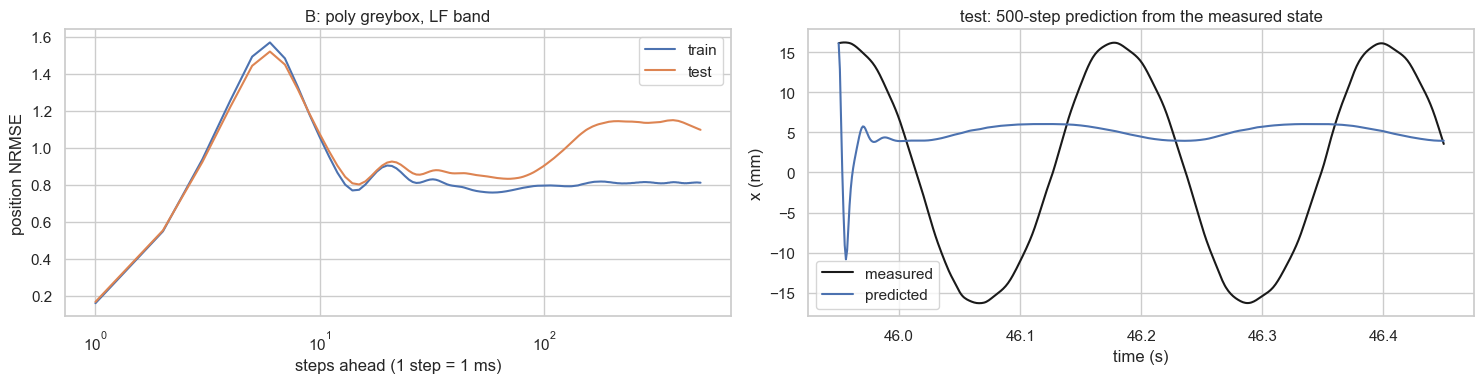

In [7]:
evaluate("C: poly greybox", poly, p_poly, "lf")

## Method D: magnet law, nonlinear greybox

Repelling Coulomb poles (PDF eq. 5), fitted on the 50-step-ahead error (LF train). $\Gamma$ and $c$ start from Stage 1, and $C_\mu$, $g_0$ from the PDF and the experiment; $g_0$ is bounded above the largest measured $|x|$:

$$m\ddot{x} = \Gamma\, i - c\,\dot{x} - 4 g_0 C_\mu \frac{x}{(g_0^2 - x^2)^2}$$

In [8]:
%%time
magnet = lambda x, q: 4 * q[1] * q[0] * x / (q[1]**2 - x**2)**2
x_max = np.abs(DATA["train"]["x"]).max()
lb = np.r_[-np.inf, -np.inf, -np.inf, 1.001 * x_max]
p_mag = fit(magnet, np.r_[p_hf[:2], CMU0, G00], DATA["train"], DATA["train"]["lf"], lb=lb)
print(f"Gamma = {p_mag[0]:.1f} N/A, c = {p_mag[1]:.1f} N s/m, C_mu = {p_mag[2]:.3f} N m^2, g0 = {p_mag[3] * 1e3:.2f} mm (|x|max {x_max * 1e3:.2f} mm)")

`xtol` termination condition is satisfied. (2 evaluations)
Gamma = 267.5 N/A, c = -273.9 N s/m, C_mu = 2.423 N m^2, g0 = 22.30 mm (|x|max 22.07 mm)
CPU times: total: 531 ms
Wall time: 475 ms


train NRMSE at k = 1, 10, 50, 500: 0.584, 208824.925, 1911231.510, 935188787.191


test  NRMSE at k = 1, 10, 50, 500: 0.079, 1.573, 596880.006, 180693723546.393


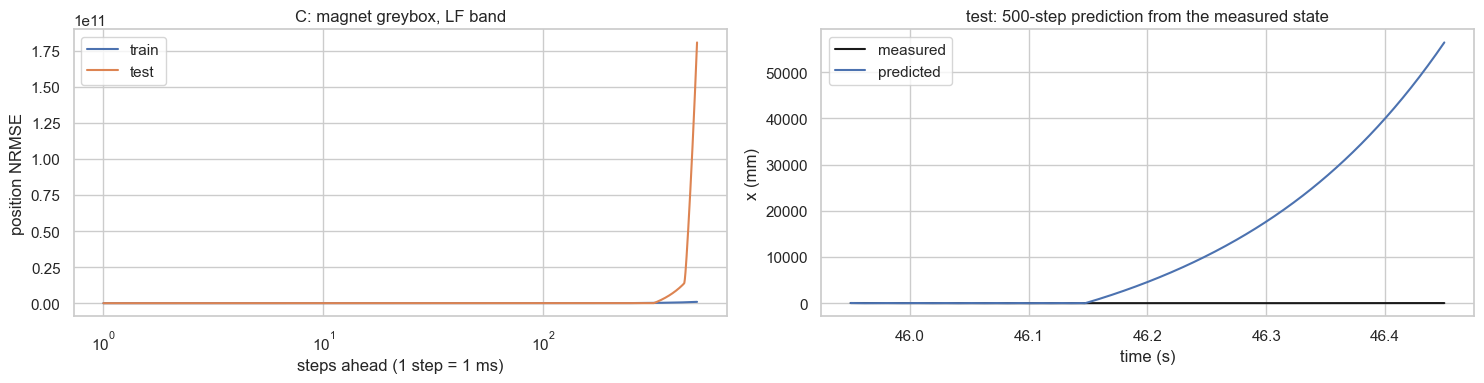

In [9]:
evaluate("D: magnet greybox", magnet, p_mag, "lf")

## Comparison (LF band)

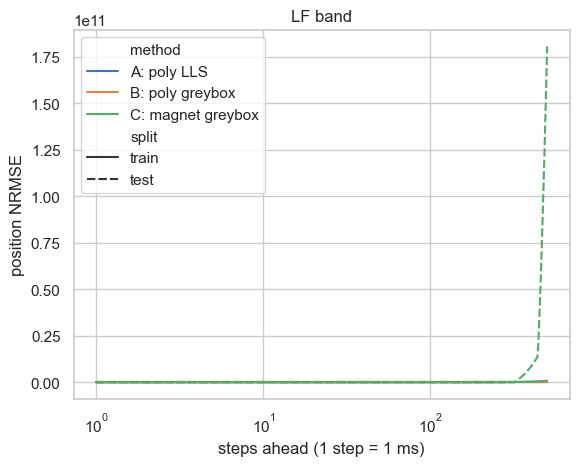

A: poly LLS        Gamma =   193.1 N/A   c =  1814.1 N s/m   k1 = 5.22e+04 N/m   f_res =  5.07 Hz
B: poly greybox    Gamma =  2262.2 N/A   c = 10231.3 N s/m   k1 = -6.11e+06 N/m   f_res =   nan Hz
C: magnet greybox  Gamma =   267.5 N/A   c =  -273.9 N s/m   k1 = 8.74e+05 N/m   f_res = 20.73 Hz


C:\Users\amato\AppData\Local\Temp\ipykernel_976332\2465966919.py:9: RuntimeWarning: invalid value encountered in sqrt
  print(f"{name:18s} Gamma = {p[0]:7.1f} N/A   c = {p[1]:7.1f} N s/m   k1 = {k1_:.3g} N/m   f_res = {np.sqrt(k1_ / M) / (2 * np.pi):5.2f} Hz")


In [10]:
lf = [c for c in CURVES if c["band"] == "lf"]
long = {key: np.concatenate([np.broadcast_to(c[key], c["k"].shape) for c in lf]) for key in ("method", "split", "k", "nrmse")}
ax = sns.lineplot(data=long, x="k", y="nrmse", hue="method", style="split")
ax.set(xscale="log", xlabel="steps ahead (1 step = 1 ms)", ylabel="position NRMSE", title="LF band")
plt.show()

k1_mag = 4 * p_mag[2] / p_mag[3]**3
for name, p, k1_ in [("A: poly3, Stage 1", p_p3, p_p3[2]), ("B: poly LLS", p_lls, p_lls[2]), ("C: poly greybox", p_poly, p_poly[2]), ("D: magnet greybox", p_mag, k1_mag)]:
    print(f"{name:18s} Gamma = {p[0]:7.1f} N/A   c = {p[1]:7.1f} N s/m   k1 = {k1_:.3g} N/m   f_res = {np.sqrt(k1_ / M) / (2 * np.pi):5.2f} Hz")